# Exploratory Data Analysis 

## Data Loading


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('../data/relationships_ai.csv')
df.head()

,Timestamp,¿En qué rango de edad te encuentras?,¿Cuál es tu área de estudio?,"¿Cuántas horas al día utilizas herramientas de IA (ChatGPT, Copilot, etc.)?",¿Con qué frecuencia utilizas herramientas de IA?,¿Cuál es el principal uso que le das a la IA?,Siento que las herramientas de IA me brindan soporte emocional.,A veces prefiero interactuar con una IA en lugar de hablar con otras personas.,Me siento incómodo(a) cuando no puedo usar herramientas de IA,Utilizo la IA para tomar decisiones personales.,Siento que la IA “me entiende”.,"En algunas situaciones, confío más en la IA que en otras personas.",¿Con qué frecuencia interactúas socialmente en persona?,"Cuando tienes un problema, ¿a quién recurres primero?",¿Has utilizado IA para apoyo emocional?,¿Prefieres el consejo de una IA sobre el de una persona en algunas situaciones?
0,4/15/2026 13:13:12,18-21,Ingeniería / STEM,2–4 horas,Varias veces al día,Estudio / tareas académicas,2,4,4,4,2,3,Rara vez,"Personas (amigos, familia)",Sí,Sí
1,4/15/2026 13:32:00,18-21,Ingeniería / STEM,1–2 horas,Varias veces al día,Estudio / tareas académicas,1,1,2,1,1,3,Muy frecuentemente,Ambos por igual,No,Sí
2,4/15/2026 13:34:36,18-21,Otro,Menos de 1 hora,Varias veces al día,Estudio / tareas académicas,5,5,1,3,3,3,Muy frecuentemente,Ambos por igual,Sí,No
3,4/15/2026 13:38:27,22-24,Ingeniería / STEM,Menos de 1 hora,Algunas veces a la semana,Entretenimiento,1,1,1,3,1,2,Muy frecuentemente,"Personas (amigos, familia)",No,No
4,4/15/2026 13:38:53,18-21,Ingeniería / STEM,1–2 horas,Una vez al día,Estudio / tareas académicas,2,1,2,1,1,3,Muy frecuentemente,"Personas (amigos, familia)",Sí,No


In [3]:
df = df.drop("Timestamp", axis=1)
df.columns = [
    'age',
    'career',
    
    # Usage
    'ai_hours',
    'ai_usage_frequency',
    'ai_usage_type',
    
    # Perception / Trust
    'ai_emotional_support_perception',
    'ai_vs_human_interaction',
    'ai_discomfort',
    'ai_decision_support',
    'ai_understanding',
    'ai_vs_human_trust',
    
    # Social behavior
    'social_interaction_frequency',
    'seeks_help_from_others',
    
    # Behavior with AI
    'uses_ai_for_emotional_support',
    'follows_ai_advice'
]


In [4]:
df = df.replace({'Sí': True, 'No': False})
df.sample(5)

,age,career,ai_hours,ai_usage_frequency,ai_usage_type,ai_emotional_support_perception,ai_vs_human_interaction,ai_discomfort,ai_decision_support,ai_understanding,ai_vs_human_trust,social_interaction_frequency,seeks_help_from_others,uses_ai_for_emotional_support,follows_ai_advice
116,22-24,Ciencias Sociales / Humanidades,1–2 horas,Una vez al día,Estudio / tareas académicas,4,4,3,2,3,3,Ocasionalmente,IA,True,False
10,18-21,Ingeniería / STEM,Menos de 1 hora,Varias veces al día,Estudio / tareas académicas,2,1,3,2,1,1,Frecuentemente,"Personas (amigos, familia)",True,False
114,+25,Ciencias Sociales / Humanidades,2–4 horas,Varias veces al día,Estudio / tareas académicas,1,1,1,1,1,1,Muy frecuentemente,"Personas (amigos, familia)",False,False
4,18-21,Ingeniería / STEM,1–2 horas,Una vez al día,Estudio / tareas académicas,2,1,2,1,1,3,Muy frecuentemente,"Personas (amigos, familia)",True,False
36,18-21,Ingeniería / STEM,1–2 horas,Varias veces al día,Estudio / tareas académicas,2,1,1,2,1,2,Frecuentemente,"Personas (amigos, familia)",False,True


In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 140 entries, 0 to 139
Data columns (total 15 columns):
 #   Column                           Non-Null Count  Dtype 
---  ------                           --------------  ----- 
 0   age                              140 non-null    str   
 1   career                           140 non-null    str   
 2   ai_hours                         140 non-null    str   
 3   ai_usage_frequency               140 non-null    str   
 4   ai_usage_type                    140 non-null    str   
 5   ai_emotional_support_perception  140 non-null    int64 
 6   ai_vs_human_interaction          140 non-null    int64 
 7   ai_discomfort                    140 non-null    int64 
 8   ai_decision_support              140 non-null    int64 
 9   ai_understanding                 140 non-null    int64 
 10  ai_vs_human_trust                140 non-null    int64 
 11  social_interaction_frequency     140 non-null    str   
 12  seeks_help_from_others           140 non-null  

In [6]:
df.describe()

,ai_emotional_support_perception,ai_vs_human_interaction,ai_discomfort,ai_decision_support,ai_understanding,ai_vs_human_trust
count,140.000000,140.000000,140.000000,140.000000,140.000000,140.000000
mean,2.300000,1.950000,1.942857,2.007143,2.092857,2.278571
std,1.284663,1.288159,1.173885,1.214401,1.296905,1.383707
min,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
25%,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
50%,2.000000,1.000000,1.000000,2.000000,2.000000,2.000000
75%,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000
max,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000


In [7]:
import pandas as pd
import numpy as np

def cronbach_alpha(df):
    # Number of items
    k = df.shape[1]
    
    # Variance of each item
    variances = df.var(ddof=1)
    
    # Total score (sum across items)
    total_score = df.sum(axis=1)
    
    # Variance of total score
    total_variance = total_score.var(ddof=1)
    
    # Cronbach's alpha formula
    alpha = (k / (k - 1)) * (1 - variances.sum() / total_variance)
    
    return alpha

# Select your Likert columns
likert_df = df[['ai_emotional_support_perception', 'ai_vs_human_interaction', 'ai_decision_support', 'ai_understanding',
                'ai_discomfort', 'ai_vs_human_trust']]

alpha = cronbach_alpha(likert_df)

print("Cronbach's alpha:", alpha)

Cronbach's alpha: 0.8692964940794057


In [8]:
for col in likert_df.columns:
    temp_df = likert_df.drop(columns=[col])
    print(col, cronbach_alpha(temp_df))

ai_emotional_support_perception 0.83872676169109
ai_vs_human_interaction 0.856774060923938
ai_decision_support 0.8406628898291486
ai_understanding 0.8230364364551439
ai_discomfort 0.876868676515806
ai_vs_human_trust 0.8413115042011228


## Target Variable

In [9]:
df['dependency_score'] = df[['ai_emotional_support_perception', 'ai_vs_human_interaction', 'ai_discomfort', 'ai_decision_support', 'ai_understanding',
                             'ai_vs_human_trust']].mean(axis=1)
bins = [1,2.5,4,5]
labels =['low', 'medium', 'high']
df['dependency_level'] = pd.cut(df['dependency_score'], bins=bins, labels=labels, include_lowest=True)
df.sample(5)

,age,career,ai_hours,ai_usage_frequency,ai_usage_type,ai_emotional_support_perception,ai_vs_human_interaction,ai_discomfort,ai_decision_support,ai_understanding,ai_vs_human_trust,social_interaction_frequency,seeks_help_from_others,uses_ai_for_emotional_support,follows_ai_advice,dependency_score,dependency_level
79,22-24,Otro,Menos de 1 hora,Rara vez,Estudio / tareas académicas,1,1,1,1,1,1,Muy frecuentemente,"Personas (amigos, familia)",False,False,1.000000,low
108,18-21,Ingeniería / STEM,1–2 horas,Varias veces al día,Estudio / tareas académicas,4,5,2,2,3,4,Ocasionalmente,Ambos por igual,True,False,3.333333,medium
103,18-21,Ingeniería / STEM,1–2 horas,Varias veces al día,Estudio / tareas académicas,3,2,4,4,4,4,Frecuentemente,"Personas (amigos, familia)",True,True,3.500000,medium
81,18-21,Ingeniería / STEM,Menos de 1 hora,Una vez al día,Estudio / tareas académicas,1,1,2,1,1,2,Muy frecuentemente,"Personas (amigos, familia)",False,False,1.333333,low
46,22-24,Negocios / Administración,2–4 horas,Varias veces al día,Trabajo,1,1,1,1,1,1,Frecuentemente,"Personas (amigos, familia)",False,False,1.000000,low


Text(0, 0.5, 'Score')

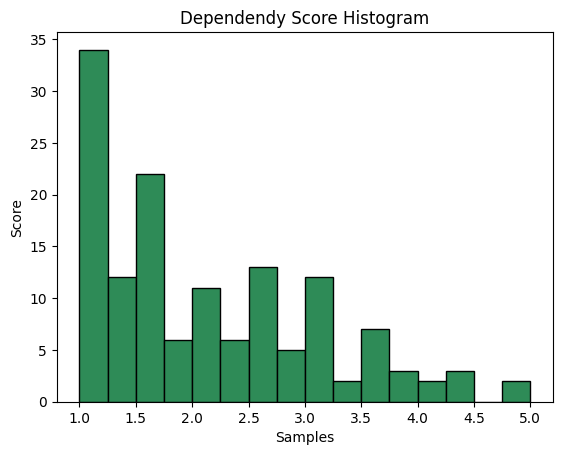

In [10]:
plt.hist(df['dependency_score'], bins=16, color='seagreen', edgecolor='black')
plt.title("Dependendy Score Histogram")
plt.xlabel("Samples")
plt.ylabel("Score")


## Correlation Analysis

Text(0.5, 1.0, 'Correlation Matrix')

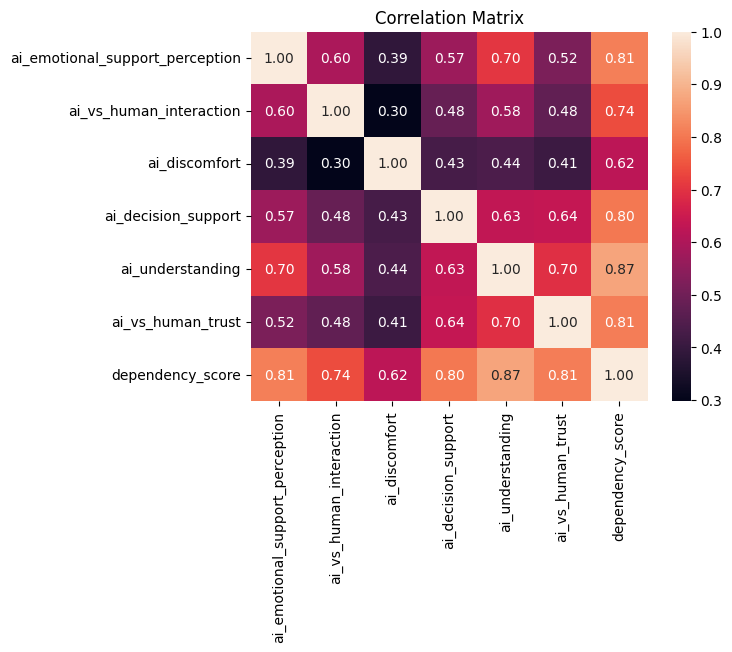

In [11]:
corr_matrix = df[['ai_emotional_support_perception', 'ai_vs_human_interaction', 'ai_discomfort', 'ai_decision_support', 'ai_understanding',
                             'ai_vs_human_trust', 'dependency_score']].corr()
sns.heatmap(corr_matrix, annot=True, fmt='.2f')
plt.title("Correlation Matrix")

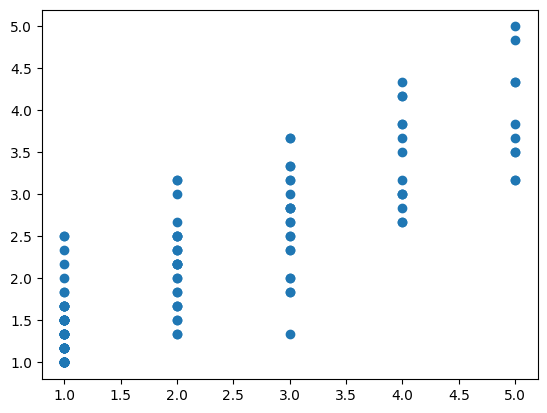

In [12]:
plt.scatter(df['ai_understanding'], df['dependency_score'])

## T-test


In [13]:
df['high_usage'] = df['ai_hours'].isin([
    '2–4 horas',
    'Más de 4 horas'
]).astype(int)
df['high_usage'].value_counts()

high_usage
0    109
1     31
Name: count, dtype: int64

In [14]:
df.sample(10)

,age,career,ai_hours,ai_usage_frequency,ai_usage_type,ai_emotional_support_perception,ai_vs_human_interaction,ai_discomfort,ai_decision_support,ai_understanding,ai_vs_human_trust,social_interaction_frequency,seeks_help_from_others,uses_ai_for_emotional_support,follows_ai_advice,dependency_score,dependency_level,high_usage
19,18-21,Otro,1–2 horas,Una vez al día,Trabajo,3,5,2,3,5,4,Rara vez,Ambos por igual,True,True,3.666667,medium,0
25,18-21,Ciencias Sociales / Humanidades,Menos de 1 hora,Algunas veces a la semana,Estudio / tareas académicas,1,1,2,1,1,1,Muy frecuentemente,"Personas (amigos, familia)",False,False,1.166667,low,0
32,18-21,Ingeniería / STEM,1–2 horas,Una vez al día,Estudio / tareas académicas,2,1,3,4,3,4,Muy frecuentemente,Ambos por igual,False,False,2.833333,medium,0
15,18-21,Ingeniería / STEM,Menos de 1 hora,Rara vez,Trabajo,1,1,1,1,1,1,Muy frecuentemente,"Personas (amigos, familia)",False,False,1.000000,low,0
111,+25,Ciencias Sociales / Humanidades,Menos de 1 hora,Una vez al día,Estudio / tareas académicas,1,1,1,1,1,1,Frecuentemente,"Personas (amigos, familia)",False,False,1.000000,low,0
72,22-24,Ingeniería / STEM,1–2 horas,Una vez al día,Estudio / tareas académicas,1,1,1,1,1,2,Muy frecuentemente,"Personas (amigos, familia)",False,False,1.166667,low,0
41,18-21,Ingeniería / STEM,Más de 4 horas,Varias veces al día,Estudio / tareas académicas,3,2,3,3,3,4,Muy frecuentemente,Ambos por igual,True,True,3.000000,medium,1
35,18-21,Ingeniería / STEM,1–2 horas,Una vez al día,Estudio / tareas académicas,3,1,2,2,2,1,Muy frecuentemente,"Personas (amigos, familia)",True,False,1.833333,low,0
57,18-21,Otro,Menos de 1 hora,Una vez al día,Estudio / tareas académicas,1,1,1,1,1,3,Frecuentemente,"Personas (amigos, familia)",True,False,1.333333,low,0
3,22-24,Ingeniería / STEM,Menos de 1 hora,Algunas veces a la semana,Entretenimiento,1,1,1,3,1,2,Muy frecuentemente,"Personas (amigos, familia)",False,False,1.500000,low,0


In [15]:
group_high = df[df['high_usage'] == 1]['dependency_score']
group_low  = df[df['high_usage'] == 0]['dependency_score']

In [16]:
n1 = len(group_high)
n2 = len(group_low)
mean1 = group_high.mean()
mean2 = group_low.mean()
var1 = group_high.var(ddof=1)
var2 = group_low.var(ddof=1)

In [17]:
se = np.sqrt((var1 / n1) + (var2 / n2))

In [18]:
t_stat = (mean1 - mean2) / se
df_num = (var1/n1 + var2/n2)**2
df_den = ((var1/n1)**2)/(n1-1) + ((var2/n2)**2)/(n2-1)
df_t = df_num / df_den

In [19]:
t_stat

np.float64(2.832136127827554)

In [20]:
from scipy.stats import t

p_value = 1 - t.cdf(t_stat, df_t)

In [21]:
p_value

np.float64(0.003488829305746677)

## Chi-squared test


In [22]:
table = pd.crosstab(
    df['social_interaction_frequency'],
    df['dependency_level']
)

print(table)

dependency_level              low  medium  high
social_interaction_frequency                   
Frecuentemente                 36       5     3
Muy frecuentemente             51      18     3
Ocasionalmente                  9       8     0
Rara vez                        3       3     1


In [23]:
# observed table
observed = table.values

# totals
row_totals = observed.sum(axis=1)
col_totals = observed.sum(axis=0)
N = observed.sum()

# expected table
expected = np.outer(row_totals, col_totals) / N

# chi-square statistic
chi2_stat = ((observed - expected)**2 / expected).sum()

print("Chi2:", chi2_stat)

Chi2: 12.407784536598628


In [24]:
r, c = observed.shape
chi_df = (r - 1) * (c - 1)

print("Degrees of freedom:", chi_df)

Degrees of freedom: 6


In [25]:
from scipy.stats import chi2

p_value = 1 - chi2.cdf(chi2_stat, chi_df)

print("p-value:", p_value)

p-value: 0.05346593692583379
